In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/train.csv', encoding='latin-1')

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [ ]:
print("Shape : ",df.shape)
print('Columns : ',df.columns.to_list())

Shape :  (9800, 18)
Columns :  ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


##Data Features

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Week_of_Year'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

In [ ]:
season_map = {
    12:0, 1:0, 2:0,
    3:1, 4:1, 5:1,
    6:2, 7:2, 8:2,
    9:3, 10:3, 11:3

}
df['Season'] = df['Month'].map(season_map)

df['Is_Holiday_Month'] = df['Month'].isin([11, 12, 1]).astype(int)
df['Is_Quarter_END'] = df['Month'].isin([3,6,9,12]).astype(int)

df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Month_Sin'] = np.sin(2*np.pi*df['Month']/12)
df['Month_Cos'] = np.cos(2*np.pi*df['Month']/12)

date_features = [
    'Day', 'Month', 'Year', 'Quarter', 'Day_of_Week', 'Week_of_Year', 'Is_Weekend',
    'Is_Holiday_Month', 'Is_Quarter_END', 'Shipping_Days', 'Month_Sin', 'Month_Cos'
]
print(f"Date features created : {len(date_features)}")
print(df[date_features].head())

Date features created : 12
   Day  Month  Year  Quarter  Day_of_Week  Week_of_Year  Is_Weekend  \
0    8     11  2017        4            2            45           0   
1    8     11  2017        4            2            45           0   
2   12      6  2017        2            0            24           0   
3   11     10  2016        4            1            41           0   
4   11     10  2016        4            1            41           0   

   Is_Holiday_Month  Is_Quarter_END  Shipping_Days     Month_Sin  Month_Cos  
0                 1               0              3 -5.000000e-01   0.866025  
1                 1               0              3 -5.000000e-01   0.866025  
2                 0               1              4  1.224647e-16  -1.000000  
3                 0               0              7 -8.660254e-01   0.500000  
4                 0               0              7 -8.660254e-01   0.500000  


##Monthly Aggregation + Lag Features

In [ ]:
monthly = df.groupby(['Year', 'Month']).agg(
    Total_Sales = ('Sales', 'sum'),
    Avg_Sales = ('Sales', 'mean'),
    Order_count = ('Order ID', 'nunique'),
    Customer_count = ('Customer ID', 'nunique')
).reset_index()

monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)

monthly['Lag_1'] = monthly['Total_Sales'].shift(1)
monthly['Lag_2'] = monthly['Total_Sales'].shift(2)
monthly['Lag_3'] = monthly['Total_Sales'].shift(3)
monthly['Lag_6'] = monthly['Total_Sales'].shift(6)
monthly['Lag_12'] = monthly['Total_Sales'].shift(12)

monthly['Rolling_3'] = monthly['Total_Sales'].shift(1).rolling(window=3).mean()
monthly['Rolling_6'] = monthly['Total_Sales'].shift(1).rolling(window=6).mean()
monthly['Rolling_12'] = monthly['Total_Sales'].shift(1).rolling(window=12).mean()

monthly['Mom_1'] = monthly['Total_Sales'] - monthly['Lag_1']
monthly['Mom_3'] = monthly['Total_Sales'] - monthly['Lag_3']

monthly['Growth_rate'] = (monthly['Total_Sales']-monthly['Lag_1'])/monthly['Lag_1']*100

monthly['Quarter'] = ((monthly['Month']-1)//3)+1

monthly['Month_Sin'] = np.sin(2*np.pi*monthly['Month']/12)
monthly['Month_Cos'] = np.cos(2*np.pi*monthly['Month']/12)

monthly['Is_Holiday_Month'] = monthly['Month'].isin([11, 12, 1]).astype(int)
monthly['Is_Quarter_END'] = monthly['Month'].isin([3,6,9,12]).astype(int)

monthly_clean = monthly.dropna()

print(f"Monthly data shape : {monthly_clean.shape}")
print("Monthly data head :")
print(monthly_clean[[
    'Year', 'Month', 'Total_Sales',
    'Lag_1', 'Lag_3', 'Rolling_3', 'Growth_rate'
]].tail(10))

Monthly data shape : (36, 22)
Monthly data head :
    Year  Month  Total_Sales        Lag_1       Lag_3     Rolling_3  \
38  2018      3   58863.4128   19920.9974  95739.1210  53045.530800   
39  2018      4   35541.9101   58863.4128  43476.4740  40753.628067   
40  2018      5   43825.9822   35541.9101  19920.9974  38108.773433   
41  2018      6   48190.7277   43825.9822  58863.4128  46077.101700   
42  2018      7   44825.1040   48190.7277  35541.9101  42519.540000   
43  2018      8   62837.8480   44825.1040  43825.9822  45613.937967   
44  2018      9   86152.8880   62837.8480  48190.7277  51951.226567   
45  2018     10   77448.1312   86152.8880  44825.1040  64605.280000   
46  2018     11  117938.1550   77448.1312  62837.8480  75479.622400   
47  2018     12   83030.3888  117938.1550  86152.8880  93846.391400   

    Growth_rate  
38   195.484265  
39   -39.619692  
40    23.307898  
41     9.959265  
42    -6.983965  
43    40.184500  
44    37.103499  
45   -10.103848  
46    

##RFM Features

In [ ]:
reference_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date',
             lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

print("RFM data stats: ")
print(rfm.describe())


RFM data stats: 
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    148.286255    6.206810   2851.874884
std     187.081466    2.525647   2620.668723
min       0.000000    1.000000      4.833000
25%      30.000000    4.000000   1081.466000
50%      75.000000    6.000000   2215.002000
75%     184.000000    8.000000   3670.258000
max    1165.000000   17.000000  25043.050000


Customer Segments :
Segment
Loyal Customers        255
Potential Loyalists    219
Champions              122
At Risk                119
Lost Customers          78
Name: count, dtype: int64


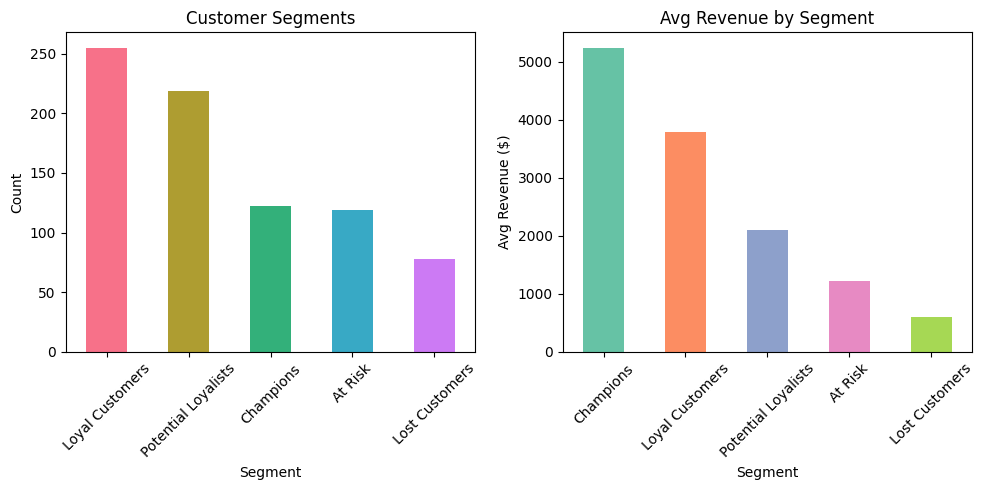

✅ RFM Features Done!


In [ ]:
import os

rfm['R_Score'] = pd.qcut(rfm['Recency'],q=5,labels=[5, 4, 3, 2, 1]).astype(int)

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=5,labels=[1, 2, 3, 4, 5]).astype(int)

rfm['M_Score'] = pd.qcut(rfm['Monetary'],q=5,labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment_customer(score):
  if score >= 13:
    return 'Champions'
  elif score >= 10:
    return "Loyal Customers"
  elif score >= 7:
    return 'Potential Loyalists'
  elif score >= 5:
    return 'At Risk'
  else:
    return "Lost Customers"

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print("Customer Segments :")
print(rfm['Segment'].value_counts())


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
rfm['Segment'].value_counts().plot(kind='bar', color=sns.color_palette('husl', 5))
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
seg_monetory = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
seg_monetory.plot(kind='bar', color=sns.color_palette('Set2', 5))
plt.title('Avg Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()

os.makedirs('notebooks', exist_ok=True)

plt.savefig(
    'notebooks/06_rfm_segments.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ RFM Features Done!")

##Category Encoding


In [ ]:
df_encoded = df.copy()

le = LabelEncoder()

categorical_cols = ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']

for col in categorical_cols:
   df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col])
   print(f"{col}: {df_encoded[col].unique()}")

Category: ['Furniture' 'Office Supplies' 'Technology']
Sub-Category: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
Region: ['South' 'West' 'Central' 'East']
Segment: ['Consumer' 'Corporate' 'Home Office']
Ship Mode: ['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [ ]:
category_dummies = pd.get_dummies(df['Category'], prefix='Cat')
df_encoded = pd.concat([df_encoded, category_dummies], axis=1)

Regional_dummies = pd.get_dummies(df['Region'], prefix='Reg')
df_encoded = pd.concat([df_encoded, Regional_dummies], axis=1)

Segment_dummies = pd.get_dummies(df['Segment'], prefix='Seg')
df_encoded = pd.concat([df_encoded, Segment_dummies], axis=1)

print(f"Encoded data shape : {df_encoded.shape}")

Encoded data shape : (9800, 56)


##Final Feature Summary

In [ ]:
all_features = {
    "Date Features": [
        'Year', 'Month', 'Day', 'Quarter', 'Day_of_Week', 'Week_of_Year', 'Is_Weekend',
        'Is_Holiday_Month', 'Is_Quarter_END', 'Shipping_Days', 'Month_Sin', 'Month_Cos'
    ],
    "Lag Features": [
        'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12'
    ],
    "Rolling Features": [
        'Rolling_3', 'Rolling_6', 'Rolling_12'
    ],
    "Momentum Features": [
        'Mom_1', 'Mom_3', 'Growth_rate'
    ],
    "RFM Features": [
        'Recency', 'Frequency', 'Monetory'
        'R_Score', 'F_Score', 'M_Score', 'RFM_Score'
    ],
    "Encoded Features": [
        'Category_Encoded', 'Region_Encoded', 'Segment_Encoded'
    ]
}

In [ ]:
total = 0
for category, features in all_features.items():
  print(f"{category} : {len(features)}")
  for f in features:
    print(f"  -> {f}")
  total += len(features)

print('='*40)
print(f"TOTAL FEATURES CREATED : {total}")
print('='*40)

os.makedirs('data', exist_ok=True)

monthly_clean.to_csv(
    'data/monthly_features.csv',
    index=False
)
rfm.to_csv(
    'data/rfm_features.csv',
    index=False
)
df_encoded.to_csv(
    'data/encoded_features.csv',
    index=False
)

Date Features : 12
  -> Year
  -> Month
  -> Day
  -> Quarter
  -> Day_of_Week
  -> Week_of_Year
  -> Is_Weekend
  -> Is_Holiday_Month
  -> Is_Quarter_END
  -> Shipping_Days
  -> Month_Sin
  -> Month_Cos
Lag Features : 5
  -> Lag_1
  -> Lag_2
  -> Lag_3
  -> Lag_6
  -> Lag_12
Rolling Features : 3
  -> Rolling_3
  -> Rolling_6
  -> Rolling_12
Momentum Features : 3
  -> Mom_1
  -> Mom_3
  -> Growth_rate
RFM Features : 6
  -> Recency
  -> Frequency
  -> MonetoryR_Score
  -> F_Score
  -> M_Score
  -> RFM_Score
Encoded Features : 3
  -> Category_Encoded
  -> Region_Encoded
  -> Segment_Encoded
TOTAL FEATURES CREATED : 32
